# Random Sample Imputation (For numerical features)

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../../../data/Titanic_dataset.csv", usecols = ['Age', 'Fare', 'Survived'])
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [5]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# making new columns to show age changes after imputation

X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age'] 

In [8]:
X_train.isnull().sum()

Age            140
Fare             0
Age_imputed    140
dtype: int64

In [9]:
# Now filling the missing values of age with random values from age feature

X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(), random_state = 42).values
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum(), random_state = 42).values

In [10]:
X_train.isnull().sum()

Age            140
Fare             0
Age_imputed      0
dtype: int64

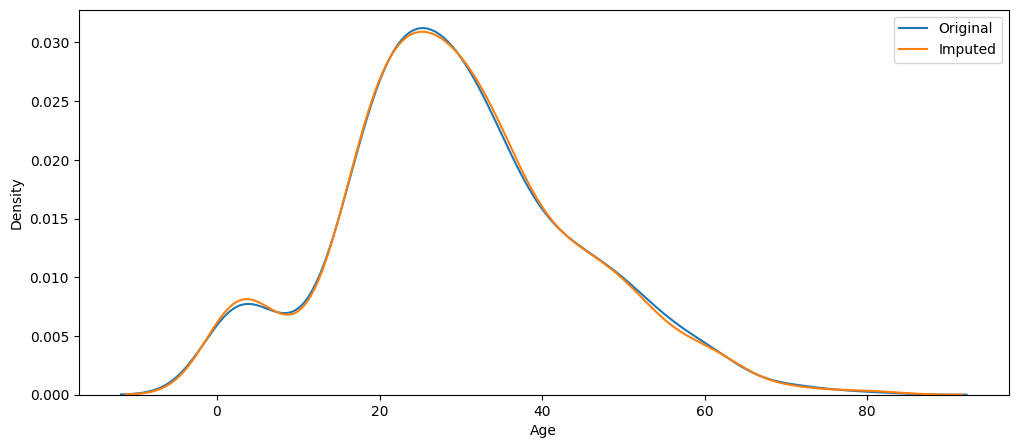

In [11]:
# Checking data distribution

plt.figure(figsize=(12, 5))

sns.kdeplot(X_train['Age'], label = 'Original')
sns.kdeplot(X_train['Age_imputed'], label ='Imputed')

plt.legend()
plt.show()

In [12]:
# checking variance

X_train['Age'].var()

np.float64(210.2517072477435)

In [13]:
X_train['Age_imputed'].var()

np.float64(210.4735711815926)

In [14]:
# variance doesnt change much

In [15]:
# Checking covariance

X_train.cov()

,Age,Fare,Age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,54.857635
Age_imputed,210.251707,54.857635,210.473571


In [16]:
# Covariance changes due to increase in randomness!

<Axes: >

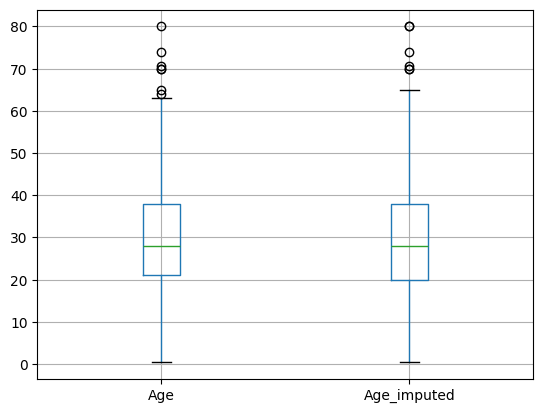

In [17]:
# Checking for outliers --

X_train[['Age', 'Age_imputed']].boxplot()

In [18]:
# No effect on outliers

In [19]:
# What if someone gives missing value in testing/production?

In [20]:
# Replace that missing val with sampled_value below [random state ensures random val doesnt change on reloading]

observation = X_train.iloc[0]

sampled_value = df['Age'].dropna().sample(1, random_state = int(observation['Fare'])).values[0]
print(sampled_value)

25.0


# Random Sample Imputation (for categorical features)

In [21]:
df_2 = pd.read_csv("../../../data/train.csv", usecols=['FireplaceQu', 'GarageQual', 'SalePrice'])
df_2.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [22]:
df_2.isnull().sum()

FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

In [23]:
df_2.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [24]:
X = df_2.drop(columns=['SalePrice'])
y = df_2['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']


In [26]:
X_train.head()

,FireplaceQu,GarageQual,GarageQual_imputed,FireplaceQu_imputed
254,NaN,TA,TA,NaN
1066,TA,TA,TA,TA
638,NaN,NaN,NaN,NaN
799,TA,TA,TA,TA
380,Gd,TA,TA,Gd


In [27]:
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum(), random_state = 42).values
X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum(), random_state = 42).values

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum(), random_state = 42).values
X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum(), random_state = 42).values

**Checking if the distribution of Garage quality changes after random sample imputation**

In [28]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [29]:
temp

,original,imputed
TA,0.951087,0.951199
Fa,0.032609,0.031678
Gd,0.011775,0.012842
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [30]:
# Distribution remains almost same and doesnt change by random sample imputation

**Checking if the distribution of Fireplace quality changes after random sample imputation**

In [31]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.491143,0.654321
TA,0.405797,0.526375
Fa,0.043478,0.056117
Ex,0.033816,0.042649
Po,0.025765,0.031425


In [32]:
# Data distribution of Fireplace Quality feature changes a lot after random sample imputation

**Plotting the kdeplots to compare the data distribution before and after imputation(random sample) for fireplace quality feature**

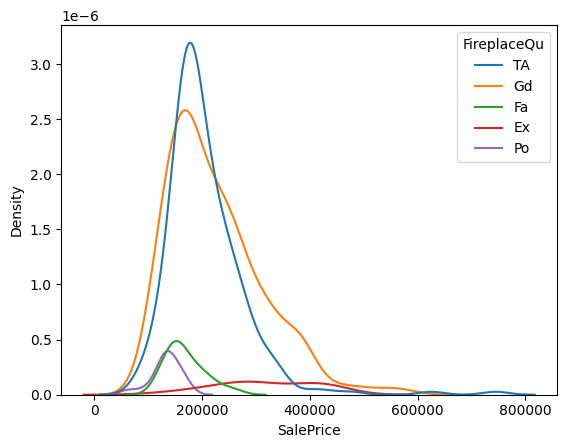

In [33]:
plot_data = X_train.join(y_train.rename('SalePrice'))
sns.kdeplot(data=plot_data, x='SalePrice', hue='FireplaceQu')
plt.show()

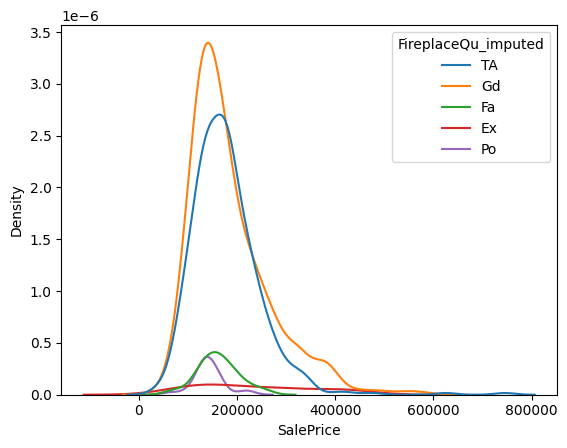

In [34]:
sns.kdeplot(data = plot_data, x = 'SalePrice', hue = 'FireplaceQu_imputed')
plt.show()

In [35]:
# When a lot of data is missing in some cases, distribution might change (when distribution changes dont use this technique)
# Usually the distribution wont change for random sample imputation

# ALWAYS check if data distribution chnages or not after applying the imputation technique

In [36]:
# done :)